In [1]:
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import netCDF4
import os
import xagg

In [2]:
scratch = '/glade/derecho/scratch/dcalhoun'

In [3]:
shapefile_path = scratch + '/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
gdf = gpd.read_file(shapefile_path)

In [4]:
gdf.columns

Index(['GISJOIN', 'STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ',
       'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP',
       'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON',
       'Shape_Leng', 'Shape_Area', 'ORIG_FID', 'geometry'],
      dtype='str')

In [50]:
gdf.rename(columns={'GEOID': 'geo_id'}, inplace=True)

In [61]:
lead_times = [12,24]
fc_files = []
for lead_time in lead_times:
    fc_paths = glob.glob(scratch + f'/ecmwf/ifs/fc/0.125/2t/*/{lead_time}/*/*/*.nc')
    for fc_path in fc_paths:
        fc_files.append((fc_path, lead_time))
n_files = len(fc_files)
print(n_files)
idxs = [int(x) for x in np.random.choice(n_files, size=4, replace=False)]
for idx in idxs:
    print(fc_files[idx])

13152
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/0000/24/2020/06/ifs_fc_2t_0000_24_20200607.nc', 24)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/1200/24/2021/04/ifs_fc_2t_1200_24_20210430.nc', 24)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/1200/24/2024/01/ifs_fc_2t_1200_24_20240126.nc', 24)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/0000/12/2022/10/ifs_fc_2t_0000_12_20221011.nc', 12)


In [63]:
len(fc_files)

13152

In [64]:
import sys
sys.path.insert(0, '/glade/u/home/dcalhoun/censuswxindex')
from censuswxindex import aggregate as wxagg

In [65]:
fc_agg = wxagg.ForecastAggregator(shapefile_path=shapefile_path, forecast_files=[fc_files[idx] for idx in idxs], var_name="t2m")

In [66]:
df_fc = fc_agg.build_data_table()

In [67]:
len(df_fc)

12436

In [68]:
fc_agg.lead_times

[12, 24]

In [69]:
df_fc

,geo_id,valid_time,init_time,lead_time,t2m
0,01001,2020-06-08 00:00:00,2020-06-07,24,299.023828
1,01003,2020-06-08 00:00:00,2020-06-07,24,297.400170
2,01005,2020-06-08 00:00:00,2020-06-07,24,297.984888
3,01007,2020-06-08 00:00:00,2020-06-07,24,299.715993
4,01009,2020-06-08 00:00:00,2020-06-07,24,301.098327
...,...,...,...,...,...
12431,56037,2022-10-11 12:00:00,2022-10-11,12,279.737999
12432,56039,2022-10-11 12:00:00,2022-10-11,12,275.357036
12433,56041,2022-10-11 12:00:00,2022-10-11,12,281.399781
12434,56043,2022-10-11 12:00:00,2022-10-11,12,281.599832


In [70]:
fc_agg.save_data_table("test_fc.csv")

In [71]:
df_fc.groupby('valid_time').t2m.describe()

,count,mean,std,min,25%,50%,75%,max
valid_time,,,,,,,,
2020-06-08 00:00:00,3109.0,298.407424,6.685895,273.952144,295.127452,299.237913,303.638198,311.939698
2021-05-01 12:00:00,3109.0,284.248391,5.057876,271.728738,280.004140,284.711406,288.128007,297.863371
2022-10-11 12:00:00,3109.0,285.551657,4.524224,269.866516,281.957006,285.781204,289.069632,298.763074
2024-01-27 12:00:00,3109.0,277.530803,6.736964,251.099051,273.408628,276.121372,281.790975,294.459326


In [72]:
df_fc.groupby('lead_time').t2m.describe()

,count,mean,std,min,25%,50%,75%,max
lead_time,,,,,,,,
12,3109.0,285.551657,4.524224,269.866516,281.957006,285.781204,289.069632,298.763074
24,9327.0,286.728873,10.689799,251.099051,278.150895,285.891420,295.334222,311.939698


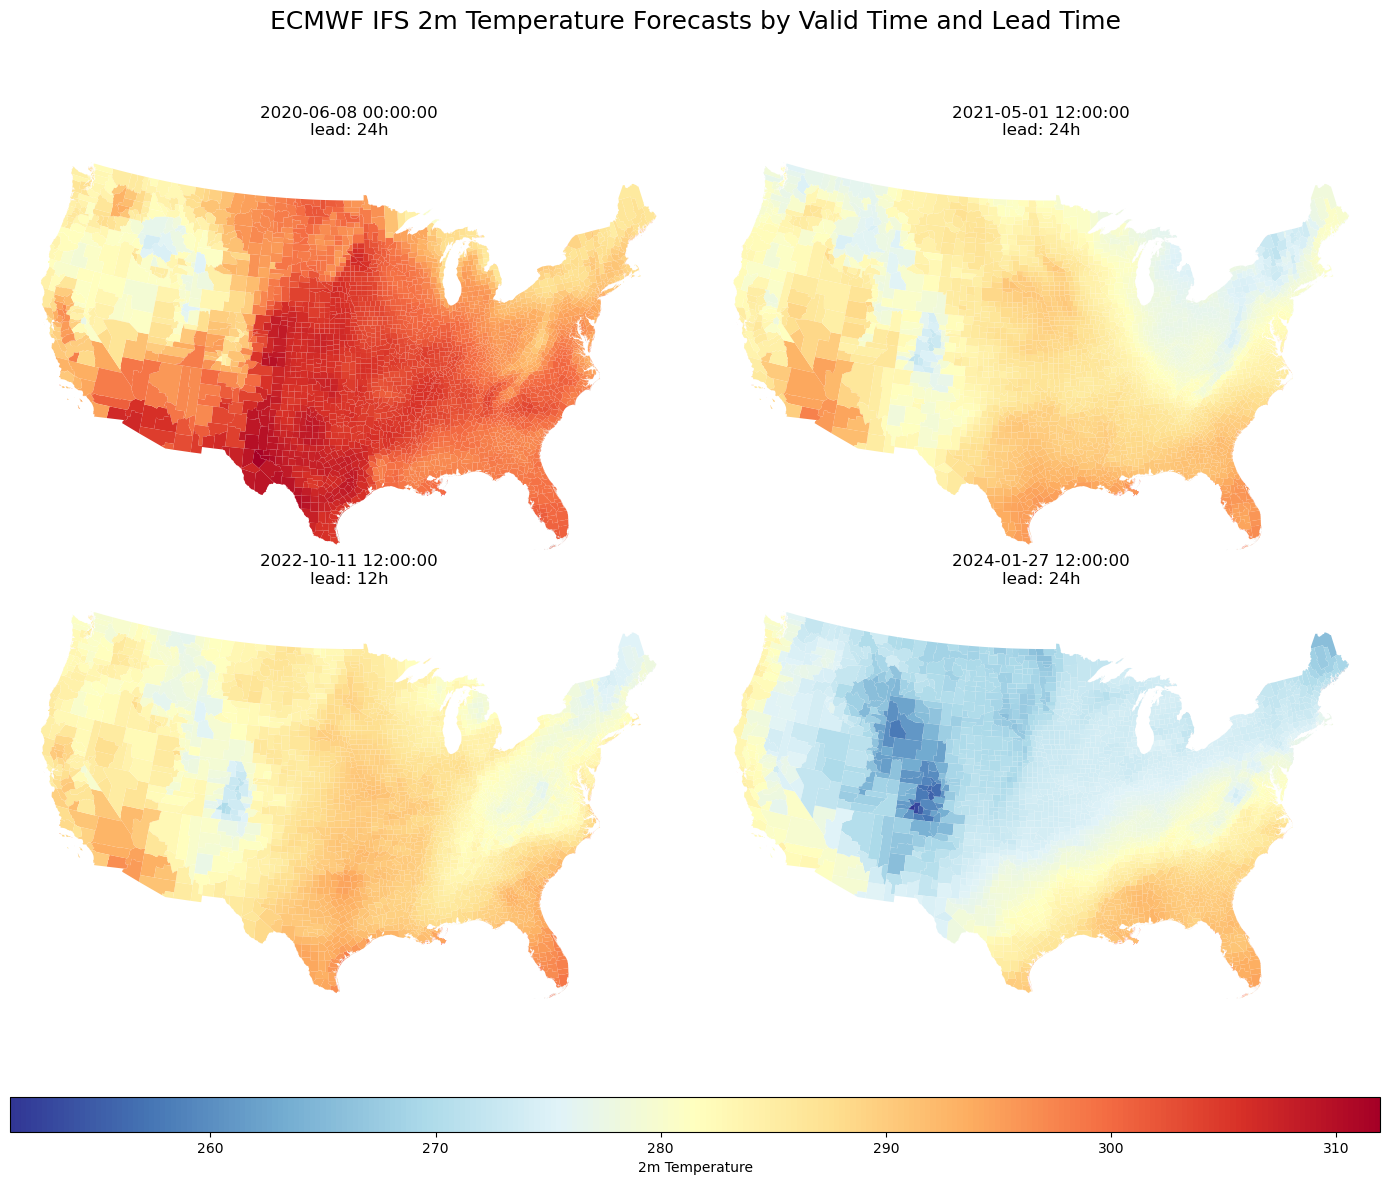

In [84]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

vmin, vmax = df_fc['t2m'].min(), df_fc['t2m'].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = 'RdYlBu_r'

for ax, (valid_time, sub) in zip(axes, df_fc.groupby('valid_time')):
    gdf_plot = gdf.merge(sub[['geo_id', 't2m']], on='geo_id', how='inner')
    gdf_plot.plot(ax=ax, column='t2m', cmap=cmap, norm=norm)
    lead_val = sub['lead_time'].iloc[0]
    ax.set_title(f'{valid_time}\nlead: {lead_val}h')
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.suptitle(
    'ECMWF IFS 2m Temperature Forecasts by Valid Time and Lead Time', 
    fontsize=18, 
    y=0.90  # Move title closer to panels
)
plt.tight_layout(rect=[0, 0.08, 1, 0.94])  # Adjust for space at bottom for colorbar and a bit at top for title

fig.colorbar(
    sm,
    ax=axes.tolist(),
    orientation='horizontal',
    fraction=0.04,
    pad=0.07,
    aspect=40,
    label='2m Temperature'
)
plt.show()